# P40-43 ish

- First let me try to figure out exactly how I want to show these vectors - I have one idea, let's see how it feels

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image
import copy
import math
import time
from tqdm import tqdm
import colorsys

import torch
import torch.nn.functional as F

# openpi imports
from openpi.training import config as _config
from openpi.policies import policy_config as _policy_config
from openpi.policies import aloha_policy
from openpi.shared import download
from openpi import transforms as _transforms
from openpi.shared import normalize as _normalize
from openpi.models import model as _model

print("Imports OK")

Imports OK


In [2]:
joint_labels = [
    "L joint 0 (waist)", "L joint 1 (shoulder)", "L joint 2 (elbow)",
    "L joint 3 (forearm)", "L joint 4 (wrist angle)", "L joint 5 (wrist rotate)",
    "L gripper",
    "R joint 0 (waist)", "R joint 1 (shoulder)", "R joint 2 (elbow)",
    "R joint 3 (forearm)", "R joint 4 (wrist angle)", "R joint 5 (wrist rotate)",
    "R gripper",
]

In [3]:
def frame_to_obs(frame):
    """Convert a HuggingFace dataset frame to the observation dict
    that the policy expects (post-RepackTransform format)."""
    def to_chw(img):
        arr = np.array(img)  # PIL -> HWC (H, W, 3)
        return arr.transpose(2, 0, 1)  # -> CHW (3, H, W)
    
    return {
        "images": {
            "cam_high": to_chw(frame["observation.images.cam_high"]),
            "cam_left_wrist": to_chw(frame["observation.images.cam_left_wrist"]),
            "cam_right_wrist": to_chw(frame["observation.images.cam_right_wrist"]),
        },
        "state": np.array(frame["observation.state"]),
        "prompt": "uncap the pen",
    }

## 1. Load Dataset

In [4]:
ds = load_dataset("physical-intelligence/aloha_pen_uncap_diverse", split="train")
print(f"Total rows: {len(ds)}")
print(f"Columns: {ds.column_names}")
print(f"Episode indices: {sorted(set(ds['episode_index']))}")

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/123 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/123 [00:00<?, ?it/s]

Total rows: 36900
Columns: ['observation.state', 'action', 'observation.velocity', 'observation.effort', 'observation.images.cam_high', 'observation.images.cam_low', 'observation.images.cam_left_wrist', 'observation.images.cam_right_wrist', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']
Episode indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122]


In [5]:
# Pick an episode and grab all its frames
EPISODE_IDX = 0

ep_indices = np.array(ds["episode_index"])
mask = ep_indices == EPISODE_IDX
row_indices = np.where(mask)[0]
episode = ds.select(row_indices)

In [6]:
# Pick a frame in the middle of the episode
FRAME_IDX = 150
frame = episode[FRAME_IDX]

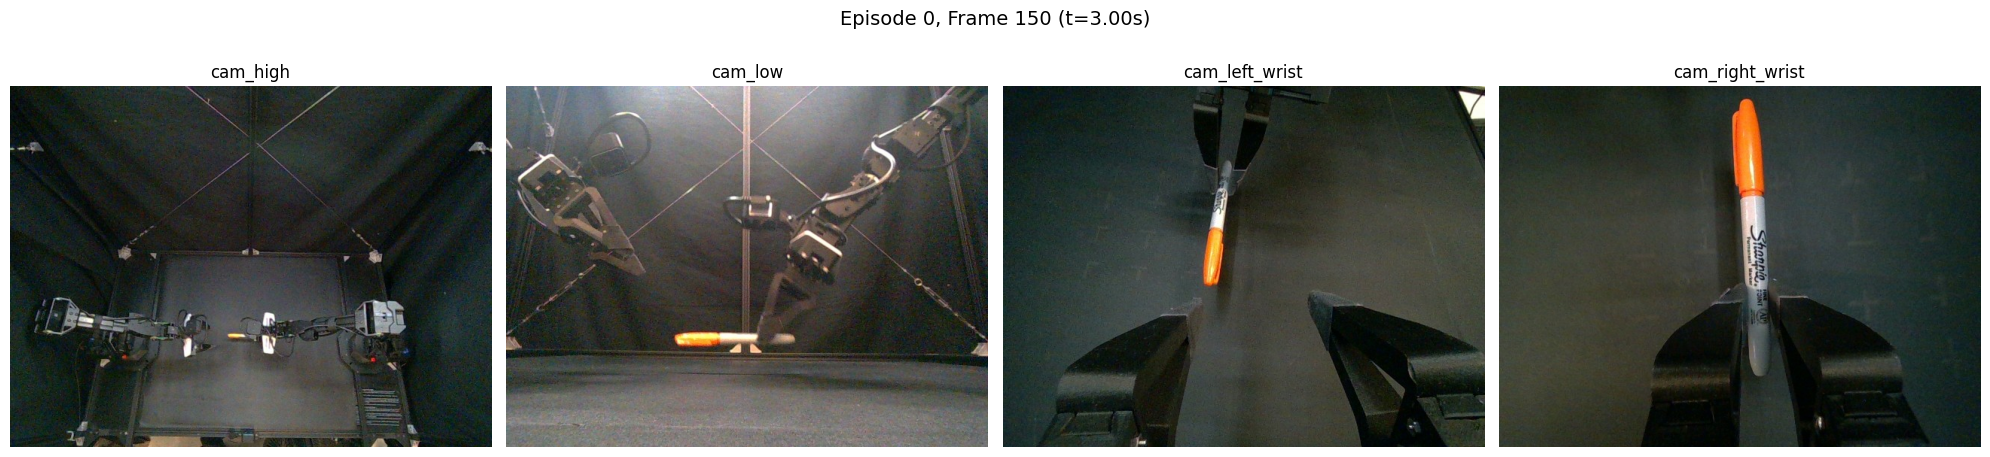

In [7]:
# Display camera views
cam_names = ["cam_high", "cam_low", "cam_left_wrist", "cam_right_wrist"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, cam_names):
    img = frame[f"observation.images.{name}"]
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle(f"Episode {EPISODE_IDX}, Frame {FRAME_IDX} (t={frame['timestamp']:.2f}s)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Load PyTorch Model

In [8]:
config = _config.get_config("pi0_aloha_pen_uncap")

# Point to converted PyTorch checkpoint
checkpoint_dir = "/home/stephen/robots/openpi/pi0_aloha_pen_uncap_pytorch"

print(f"Model type: {config.model.model_type}")
print(f"Action dim: {config.model.action_dim}")
print(f"Action horizon: {config.model.action_horizon}")

Model type: ModelType.PI0
Action dim: 32
Action horizon: 50


In [9]:
# Create the trained policy — auto-detects PyTorch format
policy = _policy_config.create_trained_policy(config, checkpoint_dir)
print(f"Policy created successfully!")
print(f"PyTorch model: {policy._is_pytorch_model}")
print(f"Device: {policy._pytorch_device}")
print(f"Number of input transforms: {len(policy._input_transform.transforms)}")
print(f"Number of output transforms: {len(policy._output_transform.transforms)}")

Policy created successfully!
PyTorch model: True
Device: cuda
Number of input transforms: 8
Number of output transforms: 3


In [10]:
# Quick reference inference to make sure the model works
obs_test = frame_to_obs(frame)
result_test = policy.infer(obs_test)
print(f"Actions shape: {result_test['actions'].shape}")
print(f"Inference time: {result_test['policy_timing']['infer_ms']:.1f} ms")

Actions shape: (50, 14)
Inference time: 23837.5 ms


## 3. Reference Inference with Fixed Noise

Generate fixed noise (using numpy so we don't need JAX at all),
run `policy.infer` as a black box, and save the result as our reference.

In [11]:
# Fix noise for reproducibility (numpy, no JAX dependency)
rng = np.random.RandomState(42)
fixed_noise = rng.randn(50, 32).astype(np.float32)
print(f"fixed_noise: {fixed_noise.shape}, dtype={fixed_noise.dtype}")
print(f"  norm={np.linalg.norm(fixed_noise):.4f}, mean={fixed_noise.mean():.4f}")

# Reference result using policy.infer as a black box
obs_ref = frame_to_obs(frame)
result_ref = policy.infer(obs_ref, noise=fixed_noise)
print(f"\nReference actions: {result_ref['actions'].shape}")
print(f"  range: [{result_ref['actions'].min():.4f}, {result_ref['actions'].max():.4f}]")

fixed_noise: (50, 32), dtype=float32
  norm=39.7640, mean=0.0398

Reference actions: (50, 14)
  range: [-0.4732, 1.1150]


## 4. Manual Reproduction — Input Transforms

Replicate what `policy.infer()` does step by step.

In [12]:
device = torch.device(policy._pytorch_device)
pt_model = policy._model  # the PI0Pytorch instance
print(f"Device: {device}")
print(f"Model type: {type(pt_model).__name__}")

Device: cuda
Model type: PI0Pytorch


In [13]:
# Step 1: Input transforms (same chain as JAX version)
obs_manual = frame_to_obs(frame)
inputs = policy._input_transform(obs_manual)

print("After input transforms:")
for k, v in inputs.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k}/{k2}: {v2.shape}, dtype={v2.dtype}")
    elif isinstance(v, np.ndarray):
        print(f"  {k}: {v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {type(v)}")

After input transforms:
  image/base_0_rgb: (224, 224, 3), dtype=uint8
  image/left_wrist_0_rgb: (224, 224, 3), dtype=uint8
  image/right_wrist_0_rgb: (224, 224, 3), dtype=uint8
  image_mask/base_0_rgb: (), dtype=bool
  image_mask/left_wrist_0_rgb: (), dtype=bool
  image_mask/right_wrist_0_rgb: (), dtype=bool
  state: (32,), dtype=float64
  tokenized_prompt: (48,), dtype=int64
  tokenized_prompt_mask: (48,), dtype=bool


In [14]:
# Step 2: Batch and convert to PyTorch tensors — each leaf [shape] -> torch [1, shape]
import jax  # just for tree.map utility, no JAX computation
inputs_pt = jax.tree.map(
    lambda x: torch.from_numpy(np.array(x)).to(device)[None, ...],
    inputs
)

print("Batched PyTorch tensors:")
for k, v in inputs_pt.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k}/{k2}: {v2.shape}, dtype={v2.dtype}, device={v2.device}")
    elif isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}, dtype={v.dtype}")

Batched PyTorch tensors:
  image/base_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image/left_wrist_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image/right_wrist_0_rgb: torch.Size([1, 224, 224, 3]), dtype=torch.uint8, device=cuda:0
  image_mask/base_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  image_mask/left_wrist_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  image_mask/right_wrist_0_rgb: torch.Size([1]), dtype=torch.bool, device=cuda:0
  state: torch.Size([1, 32]), dtype=torch.float64
  tokenized_prompt: torch.Size([1, 48]), dtype=torch.int64
  tokenized_prompt_mask: torch.Size([1, 48]), dtype=torch.bool


In [15]:
# Step 3: Build Observation dataclass
# For torch uint8 images, from_dict converts to float32 and permutes to BCHW
observation = _model.Observation.from_dict(inputs_pt)

print("Observation:")
for name, img in observation.images.items():
    print(f"  image[{name}]: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
for name, m in observation.image_masks.items():
    print(f"  mask[{name}]: {m.shape}, dtype={m.dtype}")
print(f"  state: {observation.state.shape}, dtype={observation.state.dtype}")
print(f"  tokenized_prompt: {observation.tokenized_prompt.shape}")
print(f"  tokenized_prompt_mask: {observation.tokenized_prompt_mask.shape}, valid={observation.tokenized_prompt_mask.sum()}")

Observation:
  image[base_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  image[left_wrist_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  image[right_wrist_0_rgb]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[base_0_rgb]: torch.Size([1]), dtype=torch.bool
  mask[left_wrist_0_rgb]: torch.Size([1]), dtype=torch.bool
  mask[right_wrist_0_rgb]: torch.Size([1]), dtype=torch.bool
  state: torch.Size([1, 32]), dtype=torch.float64
  tokenized_prompt: torch.Size([1, 48])
  tokenized_prompt_mask: torch.Size([1, 48]), valid=6


## 5. Preprocess + Embed Prefix

Now we enter the model internals. The PyTorch model's `_preprocess_observation`
handles image resizing, then `embed_prefix` runs SigLIP on images and embeds language tokens.

In [16]:
# Step 4: Preprocess observation (no augmentation at inference)
# This unpacks the Observation into lists that embed_prefix expects
images, img_masks, lang_tokens, lang_masks, state = pt_model._preprocess_observation(
    observation, train=False
)

print("Preprocessed observation:")
for i, (img, mask) in enumerate(zip(images, img_masks)):
    print(f"  image[{i}]: {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
    print(f"  mask[{i}]:  {mask.shape}, val={mask}")
print(f"  lang_tokens: {lang_tokens.shape}, dtype={lang_tokens.dtype}")
print(f"  lang_masks: {lang_masks.shape}, valid={lang_masks.sum()}")
print(f"  state: {state.shape}, dtype={state.dtype}")

Preprocessed observation:
  image[0]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  mask[0]:  torch.Size([1]), val=tensor([True], device='cuda:0')
  image[1]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[1]:  torch.Size([1]), val=tensor([True], device='cuda:0')
  image[2]: torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  mask[2]:  torch.Size([1]), val=tensor([True], device='cuda:0')
  lang_tokens: torch.Size([1, 48]), dtype=torch.int64
  lang_masks: torch.Size([1, 48]), valid=6
  state: torch.Size([1, 32]), dtype=torch.float64


In [17]:
# Step 5: Embed prefix using model's embed_prefix method
with torch.no_grad():
    prefix_embs, prefix_pad_masks, prefix_att_masks = pt_model.embed_prefix(
        images, img_masks, lang_tokens, lang_masks
    )

print(f"prefix_embs:      {prefix_embs.shape}, dtype={prefix_embs.dtype}")      # [1, 816, 2048]
print(f"prefix_pad_masks: {prefix_pad_masks.shape}, dtype={prefix_pad_masks.dtype}")  # [1, 816]
print(f"prefix_att_masks: {prefix_att_masks.shape}, dtype={prefix_att_masks.dtype}")  # [1, 816]

prefix_embs:      torch.Size([1, 816, 2048]), dtype=torch.bfloat16
prefix_pad_masks: torch.Size([1, 816]), dtype=torch.bool
prefix_att_masks: torch.Size([1, 816]), dtype=torch.bool


### 5b. Expand embed_prefix manually

Let's do what `embed_prefix` does, but step by step so we can inspect each piece.
This is much easier to trace than the JAX version!

In [18]:
with torch.no_grad():
    embs_list = []
    pad_mask_list = []
    ar_mask_list = []

    # --- Encode each image through SigLIP ---
    # In PyTorch: paligemma.model.get_image_features
    # This is HuggingFace's PaliGemma vision tower (SigLIP So400m/14)
    for i, (img, img_mask) in enumerate(zip(images, img_masks)):
        img_emb = pt_model.paligemma_with_expert.embed_image(img)
        bsize, num_img_tokens = img_emb.shape[:2]

        print(f"SigLIP image {i}:")
        print(f"  input:  {img.shape}, dtype={img.dtype}, range=[{img.min():.2f}, {img.max():.2f}]")
        print(f"  output: {img_emb.shape}, dtype={img_emb.dtype}")

        embs_list.append(img_emb)
        pad_mask_list.append(img_mask[:, None].expand(bsize, num_img_tokens))
        ar_mask_list += [0] * num_img_tokens

    # --- Embed language tokens ---
    # PaliGemma's embedding table + scale by sqrt(dim)
    lang_emb = pt_model.paligemma_with_expert.embed_language_tokens(lang_tokens)
    lang_emb_dim = lang_emb.shape[-1]
    lang_emb = lang_emb * math.sqrt(lang_emb_dim)

    print(f"\nLanguage embedding:")
    print(f"  token IDs: {lang_tokens.shape}, non-padding: {lang_masks.sum()}")
    print(f"  embeddings: {lang_emb.shape}, dtype={lang_emb.dtype}")

    embs_list.append(lang_emb)
    pad_mask_list.append(lang_masks)
    ar_mask_list += [0] * lang_emb.shape[1]

    # --- Concatenate into full prefix sequence ---
    prefix_embs_manual = torch.cat(embs_list, dim=1)
    prefix_pad_masks_manual = torch.cat(pad_mask_list, dim=1)

    print(f"\nFull prefix:")
    print(f"  embs:      {prefix_embs_manual.shape}  (3x256 image + 48 language = 816)")
    print(f"  pad_masks: {prefix_pad_masks_manual.shape}  (valid: {prefix_pad_masks_manual.sum()})")

    # --- Compare against reference ---
    max_diff = (prefix_embs_manual - prefix_embs).abs().max().item()
    print(f"\nMax diff vs embed_prefix reference: {max_diff}")

SigLIP image 0:
  input:  torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 0.99]
  output: torch.Size([1, 256, 2048]), dtype=torch.bfloat16
SigLIP image 1:
  input:  torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  output: torch.Size([1, 256, 2048]), dtype=torch.bfloat16
SigLIP image 2:
  input:  torch.Size([1, 3, 224, 224]), dtype=torch.float32, range=[-1.00, 1.00]
  output: torch.Size([1, 256, 2048]), dtype=torch.bfloat16

Language embedding:
  token IDs: torch.Size([1, 48]), non-padding: 6
  embeddings: torch.Size([1, 48, 2048]), dtype=torch.bfloat16

Full prefix:
  embs:      torch.Size([1, 816, 2048])  (3x256 image + 48 language = 816)
  pad_masks: torch.Size([1, 816])  (valid: 774)

Max diff vs embed_prefix reference: 0.0


- Ok let me think about how we can visualize these embedding vectors
- They're kinda long
- My vibe right now is to take the average image patch color, then build a colormap based on that
- Then do the same thing as we move throught the network
- let's se how that feels. 

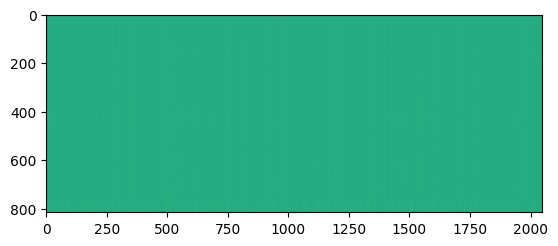

In [19]:
plt.imshow(prefix_embs_manual.detach().cpu().float().numpy()[0])

Ok what's up with this average patch color idea? 

In [20]:
inputs['image'].keys()

dict_keys(['base_0_rgb', 'left_wrist_0_rgb', 'right_wrist_0_rgb'])

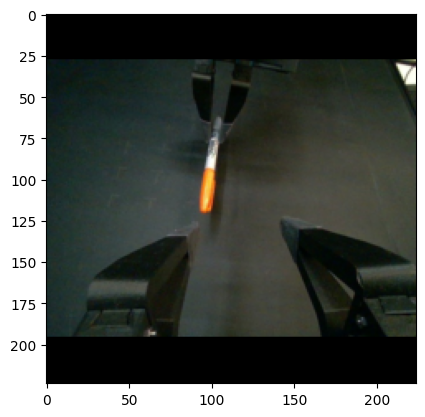

In [21]:
plt.imshow(inputs['image']['left_wrist_0_rgb'])

In [22]:
# Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
def patch_average(img):
    # (224,224,3) -> (16,14,16,14,3) -> mean over the 14x14 patch dims
    return img.reshape(16, 14, 16, 14, 3).mean(axis=(1, 3))

# def patch_bright_average(img):
#     patches = img.reshape(16, 14, 16, 14, 3)
#     brightness = patches.sum(axis=-1, keepdims=True)  # (16,14,16,14,1)
#     weights = brightness / brightness.sum(axis=(1, 3), keepdims=True)
#     return (patches * weights).sum(axis=(1, 3))  # (16, 16, 3)

def patch_bright_average(img, exponent=2.0):
    patches = img.reshape(16, 14, 16, 14, 3)
    chroma = patches.max(axis=-1, keepdims=True) - patches.min(axis=-1, keepdims=True)
    weights = chroma**exponent / (chroma**exponent).sum(axis=(1,3), keepdims=True)
    return (patches * weights).sum(axis=(1, 3))  # (16, 16, 3)

/tmp/ipykernel_1240792/4154606931.py:15: RuntimeWarning: invalid value encountered in divide
  weights = chroma**exponent / (chroma**exponent).sum(axis=(1,3), keepdims=True)


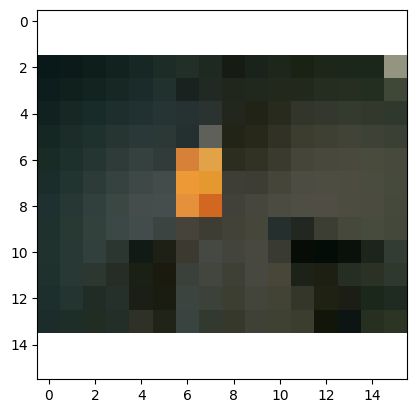

In [23]:
# patch_colors=patch_average(inputs['image']['left_wrist_0_rgb'])
patch_colors=patch_bright_average(inputs['image']['left_wrist_0_rgb'], exponent=2.0)
plt.imshow(patch_colors/255.)

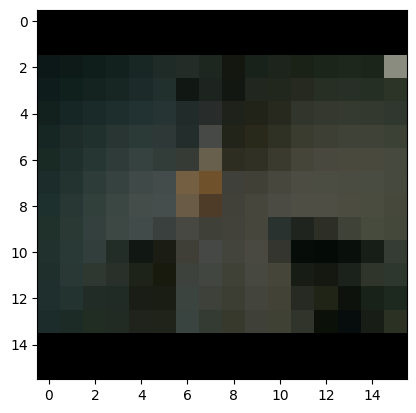

In [24]:
patch_colors=patch_average(inputs['image']['left_wrist_0_rgb'])
plt.imshow(patch_colors/255.)

- Ok dope, now let's try this crazy idea about building a colormap around each deal.
- I wonder if the brightest color would be more interseting?
- Ok found a good compomise - now let's think about how we can viz the rows.
- Ok i'm not actually sure what order the images go into Gemma - that might take a little trial and error to sort out

In [25]:
def boost_colors_hsv(colors, saturation_boost=1.0, min_saturation=0.0, min_value=0.0):
    """
    Adjust colors in HSV space for better visibility in the barcode viz.
 
    Parameters
    ----------
    colors : ndarray, shape (N, 3)
        RGB colors in [0, 1].
    saturation_boost : float
        Multiplier on S channel. 1.0 = no change, 1.5 = 50% more saturated.
    min_saturation : float in [0, 1]
        Floor for S channel. Prevents fully gray rows.
    min_value : float in [0, 1]
        Floor for V channel. Lifts dark/muddy colors so the hue reads clearly.
 
    Returns
    -------
    boosted : ndarray, shape (N, 3), dtype float32
    """
    colors = np.asarray(colors, dtype=np.float32)
    out = np.empty_like(colors)
    for i in range(len(colors)):
        h, s, v = colorsys.rgb_to_hsv(*colors[i])
        s = min(1.0, s * saturation_boost)
        s = max(s, min_saturation)
        v = max(v, min_value)
        out[i] = colorsys.hsv_to_rgb(h, s, v)
    return out
 
 
def _hsv_to_rgb_vec(hsv):
    """
    Vectorized HSV -> RGB.  hsv: (..., 3) with H in [0,1], S in [0,1], V in [0,1].
    Returns RGB (..., 3) in [0, 1].
    """
    h = hsv[..., 0]
    s = hsv[..., 1]
    v = hsv[..., 2]
 
    i = (h * 6.0).astype(np.int32) % 6
    f = (h * 6.0) - np.floor(h * 6.0)
    p = v * (1.0 - s)
    q = v * (1.0 - s * f)
    t = v * (1.0 - s * (1.0 - f))
 
    out = np.empty_like(hsv)
    for idx, (r, g, b) in enumerate([(v,t,p), (q,v,p), (p,v,t), (p,q,v), (t,p,v), (v,p,q)]):
        mask = (i == idx)
        out[..., 0] = np.where(mask, r, out[..., 0])
        out[..., 1] = np.where(mask, g, out[..., 1])
        out[..., 2] = np.where(mask, b, out[..., 2])
    return out
 
 
def render_custom_rows(embeddings, colors, padding=0.1, aspect_ratio=(1, 2), brightness_range=0.85,
                       saturation_boost=1.0, min_saturation=0.0, min_value=0.0,
                       cmap_mode='brightness'):
    """
    Render embedding vectors as colored rows with custom per-row colormaps.
 
    Parameters
    ----------
    embeddings : ndarray, shape (N, D)
        N embedding vectors of dimension D.
    colors : ndarray, shape (N, 3)
        RGB color for each row, values in [0, 1].
    padding : float in [0, 1]
        Gap between rows as a fraction of the base row height (10px).
        e.g. padding=0.1 -> 1px gap, padding=0.5 -> 5px gap.
    aspect_ratio : tuple (H, W)
        Desired aspect ratio of the output image.
    brightness_range : float in (0, 1]
        How far toward black/white the colormap extends from the base color.
        1.0 = full black-to-color-to-white. 0.5 = more subtle variation.
    saturation_boost : float
        Multiplier on HSV saturation. >1 pumps up color intensity.
    min_saturation : float in [0, 1]
        Floor for saturation. 0.3 guarantees nothing looks fully gray.
    min_value : float in [0, 1]
        Floor for HSV value. Lifts dark/muddy colors so hue reads clearly.
        e.g. 0.5 ensures no row's base color is darker than mid-gray.
    cmap_mode : str, 'brightness' or 'hsv'
        'brightness': dark <-> base color <-> white (in RGB space).
        'hsv': modulates S and V around the base color's hue.
               Low embedding values -> desaturated & darker (same hue).
               High embedding values -> more saturated & brighter (same hue).
 
    Returns
    -------
    img : ndarray, shape (total_h, total_w, 3), dtype float32
        RGB image array ready for imshow().
    """
    embeddings = np.asarray(embeddings, dtype=np.float32)
    colors = np.asarray(colors, dtype=np.float32)
 
    # Support single-row input: (D,) -> (1, D), (3,) -> (1, 3)
    if embeddings.ndim == 1:
        embeddings = embeddings[None, :]
    if colors.ndim == 1:
        colors = colors[None, :]
 
    N, D = embeddings.shape
 
    # --- NaN colors -> black ---
    nan_mask = np.any(np.isnan(colors), axis=1)  # (N,)
    if nan_mask.any():
        colors = colors.copy()
        colors[nan_mask] = 0.0  # safe placeholder for boost
 
    # --- Boost colors in HSV space ---
    if saturation_boost != 1.0 or min_saturation > 0.0 or min_value > 0.0:
        colors = boost_colors_hsv(colors, saturation_boost, min_saturation, min_value)
 
    # Re-zero NaN rows so min_value doesn't lift them
    if nan_mask.any():
        colors[nan_mask] = 0.0
 
    # --- Geometry ---
    row_h = 10
    gap_h = max(1, round(padding * row_h)) if padding > 0 else 0
 
    total_h = N * row_h + max(0, N - 1) * gap_h
    total_w = int(total_h * aspect_ratio[1] / aspect_ratio[0])
    total_w = max(total_w, 1)
 
    img = np.zeros((total_h, total_w, 3), dtype=np.float32)
 
    # --- Precompute resampling coordinates ---
    x_orig = np.linspace(0, 1, D)
    x_new = np.linspace(0, 1, total_w)
 
    for i in range(N):
        # NaN color rows stay black (img is zero-initialized)
        if nan_mask.any() and nan_mask[i]:
            continue
 
        row = embeddings[i]
 
        # Normalize to [0, 1] per row
        lo, hi = row.min(), row.max()
        if hi - lo > 1e-12:
            norm = (row - lo) / (hi - lo)
        else:
            norm = np.full_like(row, 0.5)
 
        # Resample from D -> total_w via linear interpolation
        resampled = np.interp(x_new, x_orig, norm)  # (total_w,)
 
        # --- Per-row colormap ---
        c = colors[i]  # (3,)
 
        if cmap_mode == 'brightness':
            # dark <-> color <-> white in RGB space
            dark_end = c * (1.0 - brightness_range)
            bright_end = c + (1.0 - c) * brightness_range
 
            pixels = np.empty((total_w, 3), dtype=np.float32)
            mask_lo = resampled <= 0.5
            mask_hi = ~mask_lo
 
            t_lo = (resampled[mask_lo] * 2.0)[:, None]
            pixels[mask_lo] = dark_end + t_lo * (c - dark_end)
 
            t_hi = ((resampled[mask_hi] - 0.5) * 2.0)[:, None]
            pixels[mask_hi] = c + t_hi * (bright_end - c)
 
        elif cmap_mode == 'hsv':
            # Modulate S and V around the base color's hue
            h_base, s_base, v_base = colorsys.rgb_to_hsv(*c)
 
            s_lo = s_base * (1.0 - brightness_range)
            v_lo = v_base * (1.0 - brightness_range)
            s_hi = s_base + (1.0 - s_base) * brightness_range
            v_hi = v_base + (1.0 - v_base) * brightness_range
 
            # Two-piece linear interp in HSV, same structure as brightness mode
            hsv_pixels = np.empty((total_w, 3), dtype=np.float32)
            hsv_pixels[:, 0] = h_base  # hue is constant
 
            mask_lo = resampled <= 0.5
            mask_hi = ~mask_lo
 
            t_lo = resampled[mask_lo] * 2.0      # 0->0, 0.5->1
            hsv_pixels[mask_lo, 1] = s_lo + t_lo * (s_base - s_lo)
            hsv_pixels[mask_lo, 2] = v_lo + t_lo * (v_base - v_lo)
 
            t_hi = (resampled[mask_hi] - 0.5) * 2.0  # 0.5->0, 1->1
            hsv_pixels[mask_hi, 1] = s_base + t_hi * (s_hi - s_base)
            hsv_pixels[mask_hi, 2] = v_base + t_hi * (v_hi - v_base)
 
            pixels = _hsv_to_rgb_vec(hsv_pixels)
 
        else:
            raise ValueError(f"Unknown cmap_mode: {cmap_mode!r}")
 
        # Paint into row band
        y0 = i * (row_h + gap_h)
        img[y0 : y0 + row_h] = pixels[None, :, :]  # broadcast across row height
 
    return np.clip(img, 0.0, 1.0)

In [26]:
emb_np=prefix_embs_manual.detach().cpu().float().numpy()[0]

In [27]:
emb_np.shape

(816, 2048)

In [28]:
emb_np[0]

array([ 0.91796875,  0.12255859, -0.2890625 , ...,  0.37695312,
        0.34179688, -0.44335938], dtype=float32)

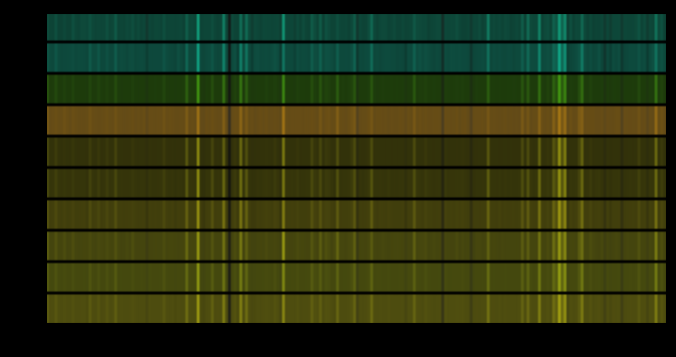

In [31]:
row_im=render_custom_rows(emb_np[:10, :], patch_colors.reshape(256, 3)[100:110]/255., 
                   padding=0.1, aspect_ratio=(1, 2), brightness_range=0.85, 
                  saturation_boost=2.0, min_saturation=0.8, min_value=0.2, cmap_mode='hsv')

fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

- Hmm ok that is kinda interesting! don't hate it! I think it will make a nice visual connection with the image
- And has nice texture/details.
- Ok another important variable here is that we're not going to show all the rows

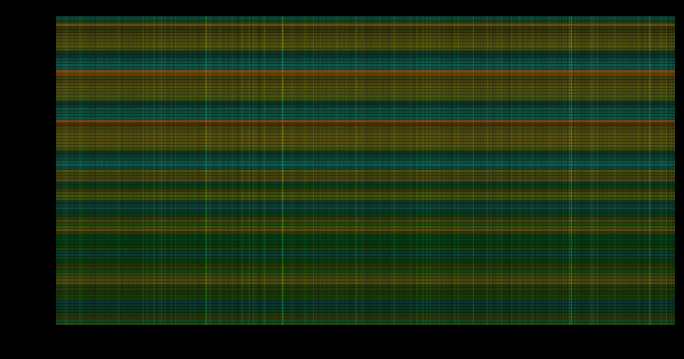

In [32]:
row_im=render_custom_rows(emb_np[:100, :], patch_colors.reshape(256, 3)[100:200]/255., 
                   padding=0.1, aspect_ratio=(1, 2), brightness_range=0.85, 
                  saturation_boost=2.0, min_saturation=0.8, min_value=0.2, cmap_mode='hsv')
fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

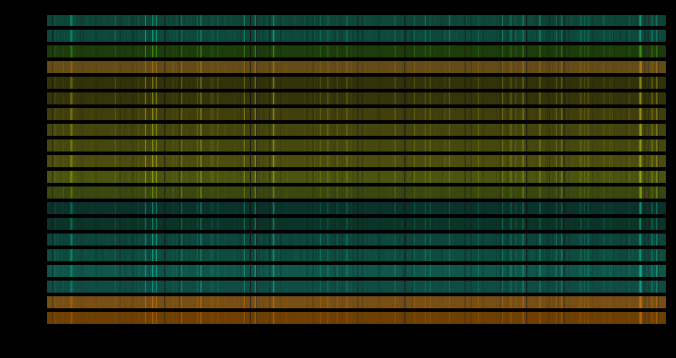

In [33]:
row_im=render_custom_rows(emb_np[:20, :], patch_colors.reshape(256, 3)[100:120]/255., 
                   padding=0.3, aspect_ratio=(1, 2), brightness_range=0.85, 
                  saturation_boost=2.0, min_saturation=0.8, min_value=0.2, cmap_mode='hsv')
fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

- I'm also not going to be rendering all the rows here - that will be a bit of a game, but we'll figure it out
- Might want to spend a second explaining what the hell I'm doing lol.
- Let's see how this looks for the queries and keys -> that's when it's going to really matter!
- Ok yeah that's cool i like those aethetics.
- Now sure exactly how I want to hanle the manim/jupyter interface here - I don't think that doing all the rendering in manim is wise -> so yeah maybe it is a raster deal like we did in the DeepSeek video
- Alright let me go hook into keys, queries, and values here. man a lot of moving pieces! This should be the most complex part of the video tho!

## 6. Prefix Forward Pass → KV Cache

Run the prefix tokens through the PaliGemma language model (18 layers) and cache the K, V.
This is the `[prefix_embs, None]` call — only expert 0 (PaliGemma) runs.

In [34]:
from openpi.models_pytorch.pi0_pytorch import make_att_2d_masks

with torch.no_grad():
    # Build attention mask
    prefix_att_2d = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_positions = torch.cumsum(prefix_pad_masks, dim=1) - 1

    print(f"prefix_att_2d: {prefix_att_2d.shape}")  # [1, 816, 816]
    print(f"prefix_positions: {prefix_positions.shape}")  # [1, 816]

    # Convert to 4D attention mask (the format HuggingFace expects)
    prefix_att_4d = pt_model._prepare_attention_masks_4d(prefix_att_2d)
    print(f"prefix_att_4d: {prefix_att_4d.shape}")  # [1, 1, 816, 816]

    # Set eager attention (not SDPA) so we can hook into it
    pt_model.paligemma_with_expert.paligemma.language_model.config._attn_implementation = "eager"

    # Forward pass: [prefix_embs, None] — only PaliGemma runs, action expert gets None
    _, kv_cache = pt_model.paligemma_with_expert.forward(
        attention_mask=prefix_att_4d,
        position_ids=prefix_positions,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

print(f"\nKV cache type: {type(kv_cache).__name__}")
print(f"KV cache layers: {len(kv_cache)}")
# Each layer has (key, value) tensors
k0, v0 = kv_cache[0]
print(f"Layer 0 K: {k0.shape}, V: {v0.shape}")  # [1, num_kv_heads, 816, head_dim]

prefix_att_2d: torch.Size([1, 816, 816])
prefix_positions: torch.Size([1, 816])
prefix_att_4d: torch.Size([1, 1, 816, 816])

KV cache type: DynamicCache
KV cache layers: 18
Layer 0 K: torch.Size([1, 1, 816, 256]), V: torch.Size([1, 1, 816, 256])


### Pre Softmax

In [35]:
attn_logits = {}
attn_weights = {}
hooks = []

def make_deep_attn_hook(layer_idx):
    original_forward = None
    
    def patched_forward(self, *args, **kwargs):
        # Run the normal forward
        kwargs['output_attentions'] = True
        result = original_forward(*args, **kwargs)
        
        # Compute logits manually from Q, K
        # We can get them by hooking the softmax input instead
        return result
    
    # Simpler approach: hook the attention dropout or softmax
    def hook_fn(module, inp, out):
        # For GemmaAttention, we can compute logits from Q and K
        # But easier: just capture both scales
        if isinstance(out, tuple) and out[1] is not None:
            attn_weights[layer_idx] = out[1].detach().cpu()
    return hook_fn

# Actually, the cleanest approach: compute logits from Q and K directly
q_captures = {}
k_captures = {}
v_captures = {}

def make_q_hook(layer_idx):
    def hook_fn(module, inp, out):
        q_captures[layer_idx] = out.detach().cpu()
    return hook_fn

def make_k_hook(layer_idx):
    def hook_fn(module, inp, out):
        k_captures[layer_idx] = out.detach().cpu()
    return hook_fn

def make_v_hook(layer_idx):
    def hook_fn(module, inp, out):
        v_captures[layer_idx] = out.detach().cpu()
    return hook_fn

pali_layers = pt_model.paligemma_with_expert.paligemma.language_model.layers
for i, layer in enumerate(pali_layers):
    hooks.append(layer.self_attn.q_proj.register_forward_hook(make_q_hook(i)))
    hooks.append(layer.self_attn.k_proj.register_forward_hook(make_k_hook(i)))
    hooks.append(layer.self_attn.v_proj.register_forward_hook(make_v_hook(i)))

with torch.no_grad():
    _, kv_cache = pt_model.paligemma_with_expert.forward(
        attention_mask=prefix_att_4d,
        position_ids=prefix_positions,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

for h in hooks:
    h.remove()

print(f"Captured Q and K for {len(q_captures)} layers")
print(f"Q shape: {q_captures[0].shape}")  # [1, 816, num_heads * head_dim]
print(f"K shape: {k_captures[0].shape}")  # [1, 816, num_kv_heads * head_dim]
print(f"V shape: {v_captures[0].shape}")  # [1, 816, num_kv_heads * head_dim]

Captured Q and K for 18 layers
Q shape: torch.Size([1, 816, 2048])
K shape: torch.Size([1, 816, 256])
V shape: torch.Size([1, 816, 256])


In [54]:
save_dir='/home/stephen/robots/mar_14_1'

import os
os.makedirs(save_dir, exist_ok=True)

In [55]:
queries=q_captures[8][0, :, 6*256:7*256].detach().cpu().float().numpy() #Should be attention head 6!
keys=k_captures[8][0, :, :].detach().cpu().float().numpy() #Should be attention head 6!
values=v_captures[8][0, :, :].detach().cpu().float().numpy() #Should be attention head 6!

In [56]:
queries.shape, keys.shape

((816, 256), (816, 256))

- Ok maybe let me go ahead and pull out the "Pen" text row? Color it cyan? Could do magenta too...
- Feeling like we do one row at a time to manim when we get there!
- Hmm should I make a big 816 of colors real quick?
- Hmm need to manually skip `</bos>` too!
- Claude says image order is base, left, right

In [57]:
inputs['image'].keys()

dict_keys(['base_0_rgb', 'left_wrist_0_rgb', 'right_wrist_0_rgb'])

In [58]:
patch_colors_1=patch_bright_average(inputs['image']['base_0_rgb'], exponent=2.0)
patch_colors_1=patch_colors_1.reshape(256, 3)
patch_colors_2=patch_bright_average(inputs['image']['left_wrist_0_rgb'], exponent=2.0)
patch_colors_2=patch_colors_2.reshape(256, 3)
patch_colors_3=patch_bright_average(inputs['image']['right_wrist_0_rgb'], exponent=2.0)
patch_colors_3=patch_colors_3.reshape(256, 3)

patch_colors_4=np.array([0, 135, 135]*48).reshape(-1, 3) #Cyan-ish bruh. Can do magenta if cyan is no beuno
patch_colors=np.vstack((patch_colors_1, patch_colors_2, patch_colors_3, patch_colors_4))

# patch_colors[np.isnan(patch_colors)]=0

/tmp/ipykernel_1240792/4154606931.py:15: RuntimeWarning: invalid value encountered in divide
  weights = chroma**exponent / (chroma**exponent).sum(axis=(1,3), keepdims=True)


/tmp/ipykernel_1240792/4154606931.py:15: RuntimeWarning: invalid value encountered in divide
  weights = chroma**exponent / (chroma**exponent).sum(axis=(1,3), keepdims=True)


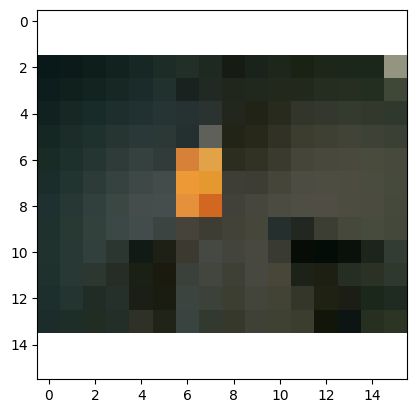

In [59]:
plt.imshow(patch_bright_average(inputs['image']['left_wrist_0_rgb'], exponent=2.0)/255.)

In [60]:
# rows_to_viz=[32, 0, 373, 374, 375, 376, 0, 769, 770, 771, 772]
# patch_colors[rows_to_viz, :]/255
# plt.imshow(np.hstack((patch_colors[rows_to_viz, :]/255, patch_colors[rows_to_viz, :]/255)))

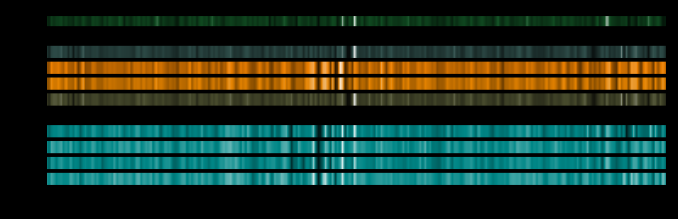

In [61]:
rows_to_viz=[32, 0, 373, 374, 375, 376, 0, 769, 770, 771, 772]
row_im=render_custom_rows(queries[rows_to_viz, :], patch_colors[rows_to_viz, :]/255., 
                   padding=0.3, aspect_ratio=(3.3, 12), brightness_range=0.85, 
                  saturation_boost=2.0, min_saturation=0.4, min_value=0.3, cmap_mode='brightness')
fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

Image.fromarray((255*row_im).astype('uint8')).save(save_dir+'/queries_2.png')

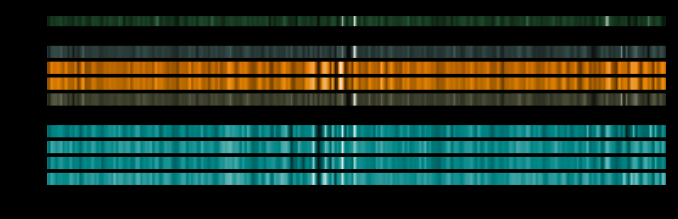

In [62]:
rows_to_viz=[32, 0, 373, 374, 375, 376, 0, 769, 770, 771, 772]
row_im=render_custom_rows(queries[rows_to_viz, :], patch_colors[rows_to_viz, :]/255., 
                   padding=0.3, aspect_ratio=(3.3, 12), brightness_range=0.85, 
                  saturation_boost=1.5, min_saturation=0.3, min_value=0.3, cmap_mode='brightness')
fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

Image.fromarray((255*row_im).astype('uint8')).save(save_dir+'/queries_2.png')

## Keys

In [63]:
#Orange gets kinda intense here, dailing back for keys
patch_colors_1=patch_bright_average(inputs['image']['base_0_rgb'], exponent=0.5)
patch_colors_1=patch_colors_1.reshape(256, 3)
patch_colors_2=patch_bright_average(inputs['image']['left_wrist_0_rgb'], exponent=0.5)
patch_colors_2=patch_colors_2.reshape(256, 3)
patch_colors_3=patch_bright_average(inputs['image']['right_wrist_0_rgb'], exponent=0.5)
patch_colors_3=patch_colors_3.reshape(256, 3)

patch_colors_4=np.array([0, 135, 135]*48).reshape(-1, 3) #Cyan-ish bruh. Can do magenta if cyan is no beuno
patch_colors=np.vstack((patch_colors_1, patch_colors_2, patch_colors_3, patch_colors_4))

/tmp/ipykernel_1240792/4154606931.py:15: RuntimeWarning: invalid value encountered in divide
  weights = chroma**exponent / (chroma**exponent).sum(axis=(1,3), keepdims=True)


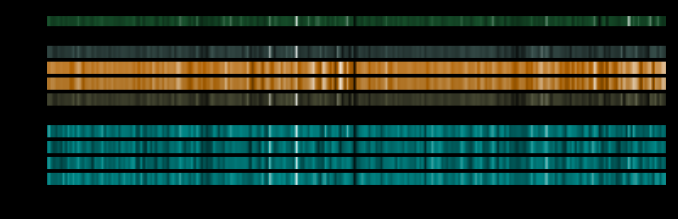

In [64]:
rows_to_viz=[32, 0, 373, 374, 375, 376, 0, 769, 770, 771, 772]
row_im=render_custom_rows(keys[rows_to_viz, :], patch_colors[rows_to_viz, :]/255., 
                   padding=0.3, aspect_ratio=(3.3, 12), brightness_range=0.85, 
                  saturation_boost=2.0, min_saturation=0.3, min_value=0.3, cmap_mode='brightness')
fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

Image.fromarray((255*row_im).astype('uint8')).save(save_dir+'/keys_1.png')

## Values

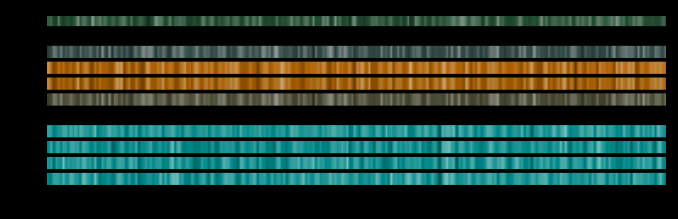

In [65]:
rows_to_viz=[32, 0, 373, 374, 375, 376, 0, 769, 770, 771, 772]
row_im=render_custom_rows(values[rows_to_viz, :], patch_colors[rows_to_viz, :]/255., 
                   padding=0.3, aspect_ratio=(3.3, 12), brightness_range=0.5, 
                  saturation_boost=1.5, min_saturation=0.3, min_value=0.3, cmap_mode='brightness')
fig=plt.figure(0, (8, 6), facecolor='k')
plt.imshow(row_im)

Image.fromarray((255*row_im).astype('uint8')).save(save_dir+'/values_1.png')

## P41
- Let me start with the dot products just for the rows I'm considering

In [66]:
dps=[]
for i in range(keys.shape[0]):
    dps.append(np.dot(queries[769], keys[i]))

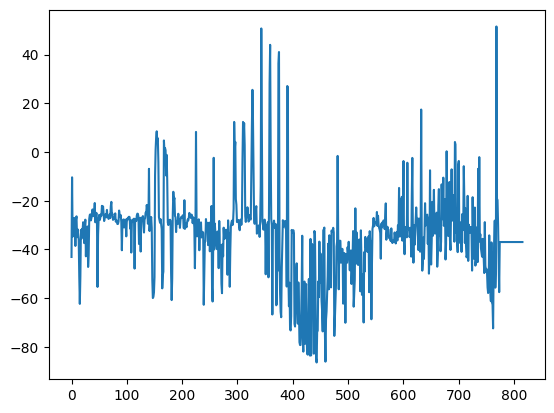

In [67]:
plt.plot(dps)

In [68]:
rows_to_viz

[32, 0, 373, 374, 375, 376, 0, 769, 770, 771, 772]

In [69]:
for r in rows_to_viz:
    print(r, dps[r])

32 -27.492645
0 -43.0689
373 -48.68993
374 36.30256
375 41.04292
376 -42.651062
0 -43.0689
769 -19.152744
770 -19.71824
771 -29.755676
772 -43.388653


- Oh wow hype that, that signal is LEGIT.
- Ok gotta run to the post office -> next will do heatmap and video! Let's go!

In [ ]:
# for i in tqdm(range(queries.shape[0])):
#     row_im=render_custom_rows(queries[i, :], patch_colors[i, :]/255., 
#                    padding=0.3, aspect_ratio=(0.5, 30), brightness_range=0.85, 
#                   saturation_boost=2.0, min_saturation=0.8, min_value=0.2, cmap_mode='hsv')
#     Image.fromarray((255*row_im).astype('uint8')).save(save_dir+'/'+str(i).zfill(3)+'.png')

In [ ]:
# i=200
# row_im=render_custom_rows(queries[i, :], patch_colors[i, :]/255., 
#                padding=0.3, aspect_ratio=(0.5, 30), brightness_range=0.85, 
#               saturation_boost=2.0, min_saturation=0.8, min_value=0.2, cmap_mode='hsv')
# im=Image.fromarray((255*row_im).astype('uint8'))

## P42 - Heatmap-ish and videos

In [70]:
# === Capture PaliGemma attention patterns ===

pali_attn_patterns = {}
hooks = []

def make_attn_hook(layer_idx):
    def hook_fn(module, inp, output):
        # GemmaAttention.forward returns (attn_output, attn_weights, ...)
        if isinstance(output, tuple) and len(output) >= 2 and output[1] is not None:
            # attn_weights shape: [batch, num_heads, seq_len, seq_len]
            pali_attn_patterns[layer_idx] = output[1].detach().cpu()
    return hook_fn

pali_layers = pt_model.paligemma_with_expert.paligemma.language_model.layers
for i, layer in enumerate(pali_layers):
    h = layer.self_attn.register_forward_hook(make_attn_hook(i))
    hooks.append(h)

print(f"Hooked {len(hooks)} attention layers")

# Run the prefix forward pass
with torch.no_grad():
    _, kv_cache = pt_model.paligemma_with_expert.forward(
        attention_mask=prefix_att_4d,
        position_ids=prefix_positions,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

# Clean up hooks
for h in hooks:
    h.remove()

# Check what we captured
print(f"\nCaptured {len(pali_attn_patterns)} layers")
for layer_idx in sorted(pali_attn_patterns.keys()):
    attn = pali_attn_patterns[layer_idx]
    print(f"  layer {layer_idx}: {attn.shape}")
    # Expecting [1, 8, 816, 816] — 8 query heads, 816 tokens

Hooked 18 attention layers

Captured 18 layers
  layer 0: torch.Size([1, 8, 816, 816])
  layer 1: torch.Size([1, 8, 816, 816])
  layer 2: torch.Size([1, 8, 816, 816])
  layer 3: torch.Size([1, 8, 816, 816])
  layer 4: torch.Size([1, 8, 816, 816])
  layer 5: torch.Size([1, 8, 816, 816])
  layer 6: torch.Size([1, 8, 816, 816])
  layer 7: torch.Size([1, 8, 816, 816])
  layer 8: torch.Size([1, 8, 816, 816])
  layer 9: torch.Size([1, 8, 816, 816])
  layer 10: torch.Size([1, 8, 816, 816])
  layer 11: torch.Size([1, 8, 816, 816])
  layer 12: torch.Size([1, 8, 816, 816])
  layer 13: torch.Size([1, 8, 816, 816])
  layer 14: torch.Size([1, 8, 816, 816])
  layer 15: torch.Size([1, 8, 816, 816])
  layer 16: torch.Size([1, 8, 816, 816])
  layer 17: torch.Size([1, 8, 816, 816])


In [71]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google/paligemma-3b-pt-224")
print(tokenizer.decode([2]))  # sanity check

<bos>


In [116]:
attn=pali_attn_patterns[8][0,6].float().numpy()

#I guess row is the vibe?
attn_row=attn[769, :]

cam_attn_1=attn_row[:256].reshape(16,16)
cam_attn_2=attn_row[256:512].reshape(16,16)
cam_attn_3=attn_row[512:768].reshape(16,16)

cam_attn_1u = np.array(Image.fromarray(cam_attn_1.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
cam_attn_2u = np.array(Image.fromarray(cam_attn_2.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
cam_attn_3u = np.array(Image.fromarray(cam_attn_3.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))

In [117]:
inputs['image'].keys()

dict_keys(['base_0_rgb', 'left_wrist_0_rgb', 'right_wrist_0_rgb'])

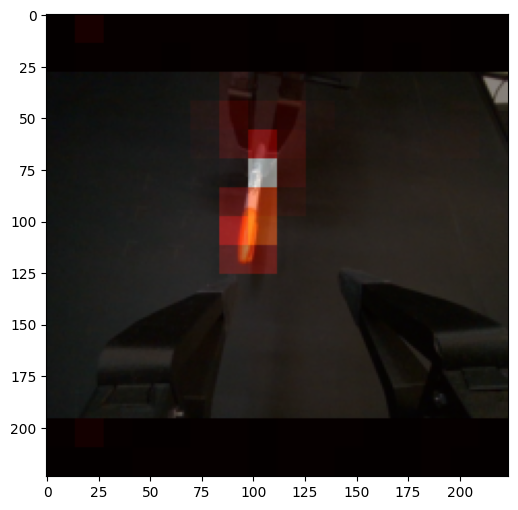

In [118]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)
ax.imshow(inputs['image']['left_wrist_0_rgb'])
ax.imshow(cam_attn_2u, cmap='hot', alpha=0.5) #, vmin=vmin, vmax=vmax)

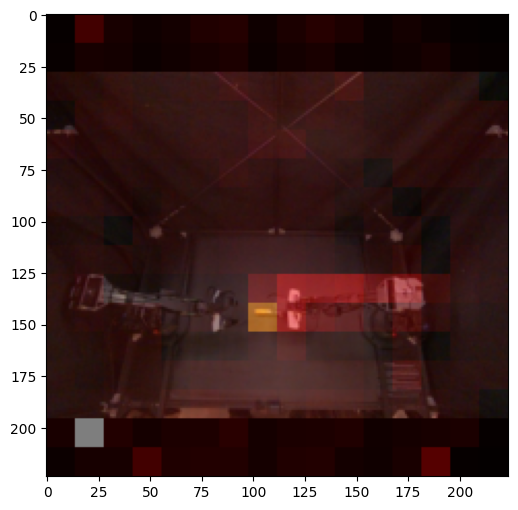

In [119]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)
ax.imshow(inputs['image']['base_0_rgb'])
ax.imshow(cam_attn_1u, cmap='hot', alpha=0.5) #, vmin=vmin, vmax=vmax)

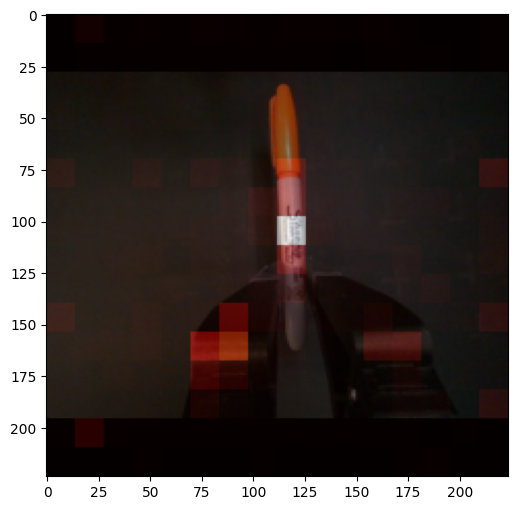

In [120]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)
ax.imshow(inputs['image']['right_wrist_0_rgb'])
ax.imshow(cam_attn_3u, cmap='hot', alpha=0.5) #, vmin=vmin, vmax=vmax)

- These look great!
- Ok ok ok ok, now how to we want to handle the patchified version?
- Little like yellow squares around each patch are very clean -> but I still realy like the heatmap for some reason
- I feel like each each patch should have a single heatmap value tho!

In [135]:
def split_with_padding(img, padding=4):
    N = img.shape[0]
    p = N // 16
    new_size = N + padding * 15

    if img.ndim == 3:
        out = np.zeros((new_size, new_size, img.shape[2]), dtype=img.dtype)
    else:
        out = np.zeros((new_size, new_size), dtype=img.dtype)

    for i in range(16):
        for j in range(16):
            sy = i * (p + padding)
            sx = j * (p + padding)
            out[sy:sy+p, sx:sx+p] = img[i*p:(i+1)*p, j*p:(j+1)*p]
    return out

In [136]:
im_left_split=split_with_padding(inputs['image']['left_wrist_0_rgb'], 2)

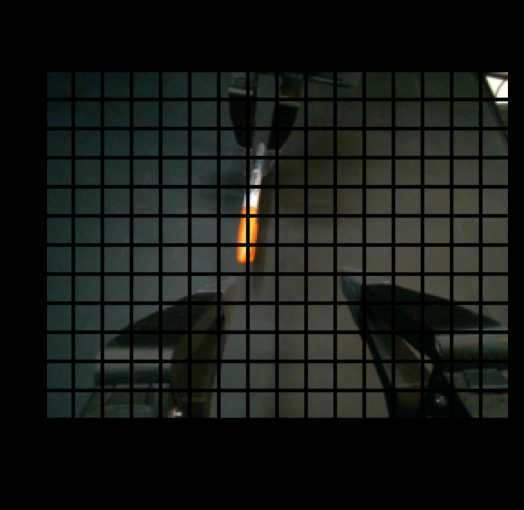

In [137]:
fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)
plt.imshow(im_left_split)

In [138]:
cam_attn_2.shape

(16, 16)

In [142]:
# plt.imshow(cam_attn_2, cmap='hot', alpha=0.5)

In [175]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

hot_full = cm.get_cmap('hot')
hot_truncated = LinearSegmentedColormap.from_list(
    'hot_trunc', hot_full(np.linspace(0, 0.65, 256))
)

/tmp/ipykernel_1240792/1604312254.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hot_full = cm.get_cmap('hot')


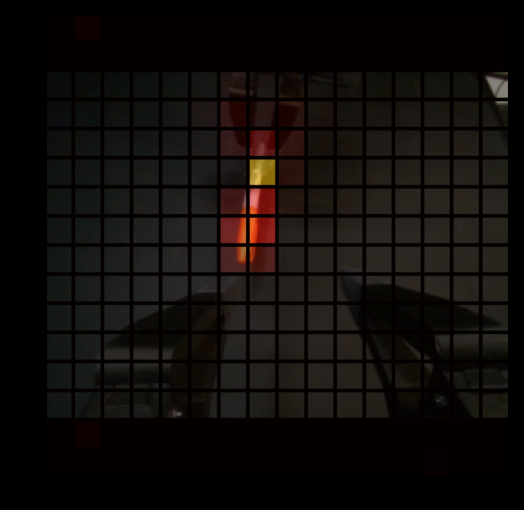

In [176]:
cam_attn=cam_attn_2

# threshold = np.percentile(cam_attn, 90)
cam_attn = np.array(Image.fromarray(cam_attn.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
heatmap_split=split_with_padding(cam_attn, 2)

# heatmap_split_masked = np.where(heatmap_split >= threshold, heatmap_split, np.nan)

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)

ax.imshow(im_left_split)
ax.imshow(heatmap_split, cmap=hot_truncated, alpha=0.5) #, vmax=1.5*cam_attn_2u.max())

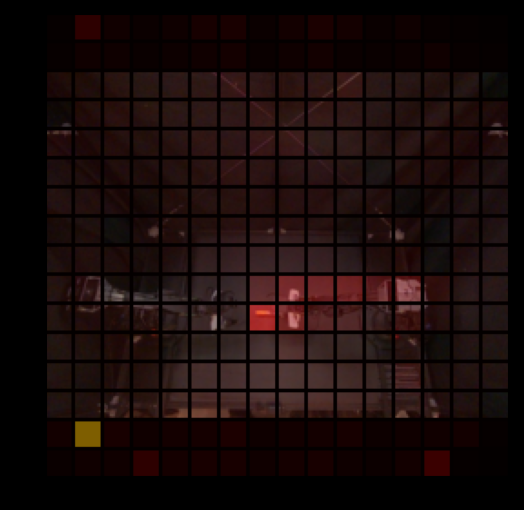

In [177]:
im_split=split_with_padding(inputs['image']['base_0_rgb'], 2)

cam_attn_u = np.array(Image.fromarray(cam_attn_1.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
heatmapt_split=split_with_padding(cam_attn_u, 2)

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)

ax.imshow(im_split)
ax.imshow(heatmapt_split, cmap=hot_truncated, alpha=0.5) #, vmax=1.5*cam_attn_2u.max())

In [178]:
inputs['image']['base_0_rgb'].shape

(224, 224, 3)

In [179]:
cam_attn_u.shape

(224, 224)

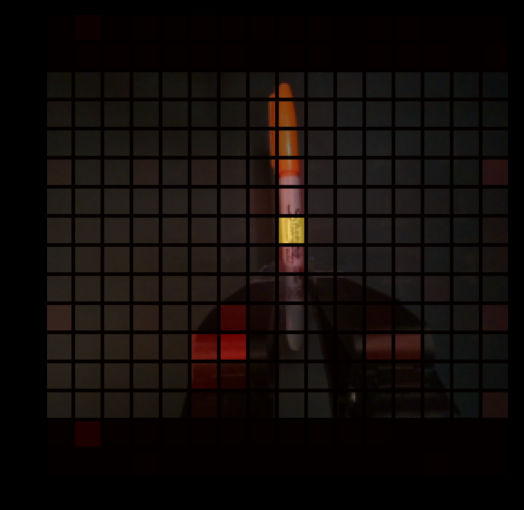

In [180]:
im_split=split_with_padding(inputs['image']['right_wrist_0_rgb'], 2)

cam_attn_u = np.array(Image.fromarray(cam_attn_3.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
heatmapt_split=split_with_padding(cam_attn_u, 2)

fig=plt.figure(0, (6,6), facecolor='k')
ax=fig.add_subplot(111)

ax.imshow(im_split)
ax.imshow(heatmapt_split, cmap=hot_truncated, alpha=0.5) #, vmax=1.5*cam_attn_2u.max())

- Ok truncated version of colormap is not bad
- Let's try video version!

In [196]:
save_dir='/home/stephen/robots/mar_14_2'

import os
os.makedirs(save_dir, exist_ok=True)

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

hot_full = cm.get_cmap('hot')
hot_truncated = LinearSegmentedColormap.from_list(
    'hot_trunc', hot_full(np.linspace(0, 0.62, 256))
)

/tmp/ipykernel_1240792/1663479638.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hot_full = cm.get_cmap('hot')


  0%|▏                                         | 1/300 [00:00<04:42,  1.06it/s]/tmp/ipykernel_1240792/2725013745.py:73: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (16,9), facecolor='k')
  1%|▎                                         | 2/300 [00:01<04:24,  1.13it/s]/tmp/ipykernel_1240792/2725013745.py:73: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (16,9), facecolor='k')
  1%|▍                                         | 3/300 [00:02<04:20,  1.14it/s]/tmp/ipykernel_1240792/2725013745.py:73: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  fig=plt.figure(0, (16,9), facecolor='k')
  1%|▌                                         | 4/300 [00:03<04:15,  1.16it/s]/tmp/ipykernel_1240792/2725013745.py:73: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  f

<Figure size 640x480 with 0 Axes>

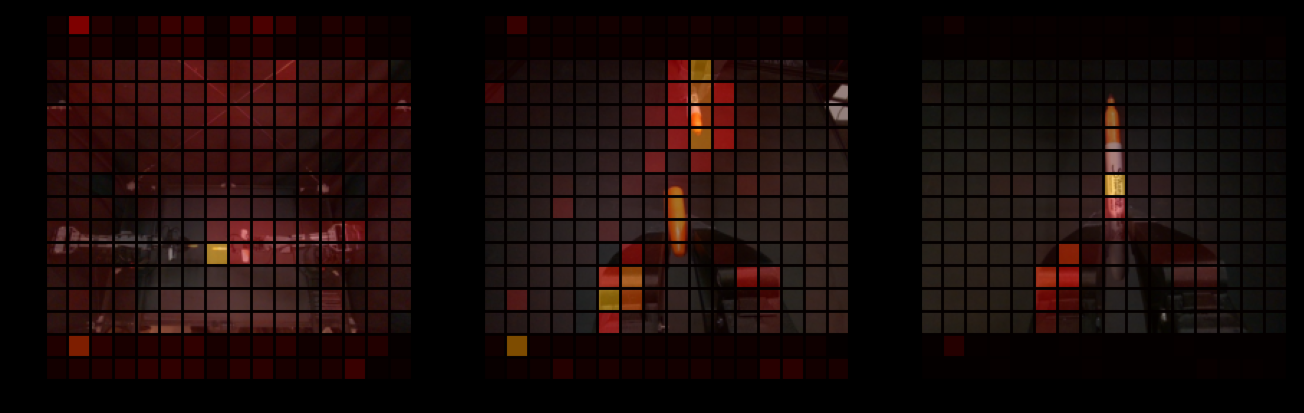

In [200]:
# Pick an episode and grab all its frames
EPISODE_IDX = 0

ep_indices = np.array(ds["episode_index"])
mask = ep_indices == EPISODE_IDX
row_indices = np.where(mask)[0]
episode = ds.select(row_indices)


# FRAME_IDX = 0

for FRAME_IDX in tqdm(range(len(episode))):
    frame = episode[FRAME_IDX]
    
    obs_manual = frame_to_obs(frame)
    inputs = policy._input_transform(obs_manual)
    
    inputs_pt = jax.tree.map(
        lambda x: torch.from_numpy(np.array(x)).to(device)[None, ...],
        inputs
    )
    
    observation = _model.Observation.from_dict(inputs_pt)
    
    images, img_masks, lang_tokens, lang_masks, state = pt_model._preprocess_observation(
        observation, train=False
    )
    
    with torch.no_grad():
        prefix_embs, prefix_pad_masks, prefix_att_masks = pt_model.embed_prefix(
            images, img_masks, lang_tokens, lang_masks
        )
    
    # === Capture PaliGemma attention patterns ===
    
    pali_attn_patterns = {}
    hooks = []
    
    pali_layers = pt_model.paligemma_with_expert.paligemma.language_model.layers
    for i, layer in enumerate(pali_layers):
        h = layer.self_attn.register_forward_hook(make_attn_hook(i))
        hooks.append(h)
    
    
    # Run the prefix forward pass
    with torch.no_grad():
        _, kv_cache = pt_model.paligemma_with_expert.forward(
            attention_mask=prefix_att_4d,
            position_ids=prefix_positions,
            past_key_values=None,
            inputs_embeds=[prefix_embs, None],
            use_cache=True,
        )
    
    # Clean up hooks
    for h in hooks:
        h.remove()
    
    attn=pali_attn_patterns[8][0,6].float().numpy()
    
    #I guess row is the vibe?
    attn_row=attn[769, :]
    
    cam_attn_1=attn_row[:256].reshape(16,16)
    cam_attn_2=attn_row[256:512].reshape(16,16)
    cam_attn_3=attn_row[512:768].reshape(16,16)
    
    cam_attn_1u = np.array(Image.fromarray(cam_attn_1.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
    cam_attn_2u = np.array(Image.fromarray(cam_attn_2.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
    cam_attn_3u = np.array(Image.fromarray(cam_attn_3.astype(np.float32)).resize((224, 224), resample=Image.NEAREST))
    
    plt.clf()
    fig=plt.figure(0, (16,9), facecolor='k')
    
    im_split=split_with_padding(inputs['image']['base_0_rgb'], 2)
    heatmapt_split=split_with_padding(cam_attn_1u, 2)
    
    ax=fig.add_subplot(131)
    ax.imshow(im_split)
    ax.imshow(heatmapt_split, cmap=hot_truncated, alpha=0.5) #, vmax=1.5*cam_attn_2u.max())
    
    im_split=split_with_padding(inputs['image']['left_wrist_0_rgb'], 2)
    heatmapt_split=split_with_padding(cam_attn_2u, 2)
    ax=fig.add_subplot(132)
    ax.imshow(im_split)
    ax.imshow(heatmapt_split, cmap=hot_truncated, alpha=0.5) 
    
    im_split=split_with_padding(inputs['image']['right_wrist_0_rgb'], 2)
    heatmapt_split=split_with_padding(cam_attn_3u, 2)
    ax=fig.add_subplot(133)
    ax.imshow(im_split)
    ax.imshow(heatmapt_split, cmap=hot_truncated, alpha=0.5) 

    plt.savefig(save_dir+'/'+str(FRAME_IDX).zfill(3)+'.png', dpi=150)

<Figure size 640x480 with 0 Axes>

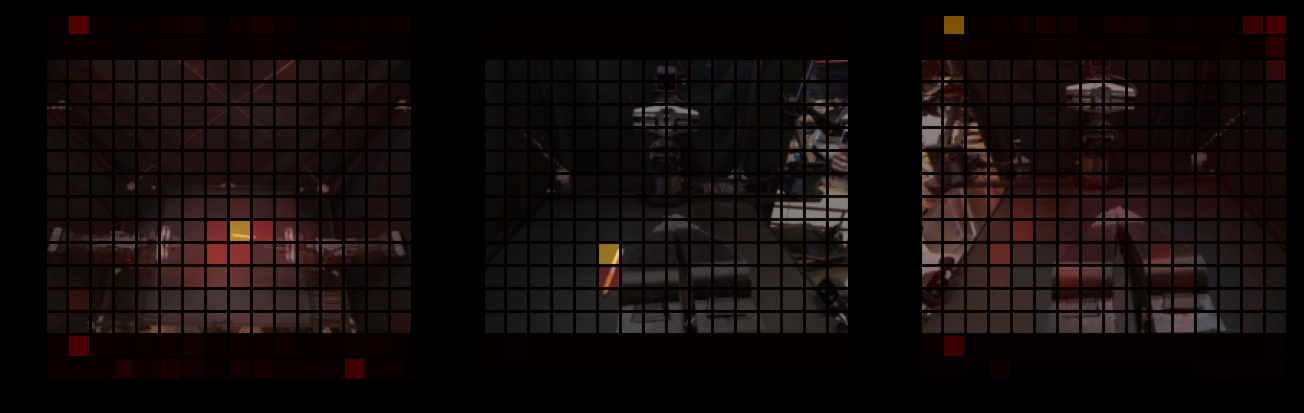

Defintiely want to a basic video version working at this point - good sanity check and i think it's cool!

In [23]:
# """
# Pi0 PaliGemma Attention Pattern Visualizer
# ==========================================
# Paste this into the notebook after cell 33 (where pali_attn_patterns is populated).

# Expects these variables in scope:
#   - pali_attn_patterns: dict[int, Tensor]  — layer_idx -> [1, 8, 816, 816]
#   - lang_tokens: Tensor [1, 48]            — tokenized prompt IDs
#   - lang_masks: Tensor [1, 48]             — 1 for valid, 0 for padding
#   - frame: dict                            — the HF dataset frame (for camera images)
#   - pt_model                               — the PI0Pytorch model (for tokenizer access)
# """

# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from matplotlib.colors import Normalize
# from PIL import Image

# # ─────────────────────────────────────────────────────────
# # CONFIG
# # ─────────────────────────────────────────────────────────
# OUTPUT_DIR = "/home/stephen/robots/mar_10_1"
# TOP_K = 5           # number of top-attended patches to highlight per image
# PATCH_GRID = 16     # SigLIP So400m/14 on 224x224 → 16x16 grid
# NUM_IMG_TOKENS = PATCH_GRID * PATCH_GRID  # 256

# # Camera layout in the 816-token prefix:
# #   [0:256]   = cam_high
# #   [256:512] = cam_left_wrist
# #   [512:768] = cam_right_wrist
# #   [768:816] = language tokens (48 slots)
# CAM_SLICES = {
#     "cam_high":       slice(0, 256),
#     "cam_left_wrist": slice(256, 512),
#     "cam_right_wrist": slice(512, 768),
# }
# LANG_OFFSET = 768

# CAM_KEYS_IN_FRAME = {
#     "cam_high":       "observation.images.cam_high",
#     "cam_left_wrist": "observation.images.cam_left_wrist",
#     "cam_right_wrist": "observation.images.cam_right_wrist",
# }




# def decode_prompt_tokens(pt_model, lang_tokens, lang_masks):
#     """Decode each valid language token to its string representation."""
#     # tokenizer = pt_model.paligemma_with_expert.paligemma.tokenizer
    
#     valid_mask = lang_masks[0].bool()
#     token_ids = lang_tokens[0][valid_mask].tolist()
    
#     token_strings = []
#     for tid in token_ids:
#         decoded = tokenizer.decode([tid])
#         token_strings.append(decoded)
    
#     # Also return the positions in the 816-token sequence
#     valid_indices = valid_mask.nonzero(as_tuple=True)[0].tolist()
#     prefix_positions = [LANG_OFFSET + idx for idx in valid_indices]
    
#     return token_strings, token_ids, prefix_positions


# def get_camera_images(frame):
#     """Extract camera images as numpy arrays (H, W, 3)."""
#     images = {}
#     for cam_name, frame_key in CAM_KEYS_IN_FRAME.items():
#         img = frame[frame_key]
#         if isinstance(img, Image.Image):
#             img = np.array(img)
#         images[cam_name] = img
#     return images


# def overlay_attention_on_image(ax, img, attn_16x16, top_k=TOP_K, title="",
#                                 vmin=None, vmax=None, show_colorbar=False):
#     """
#     Overlay a 16x16 attention heatmap on a camera image.
#     Draw bounding boxes around the top-k attended patches.
#     """
#     h, w = img.shape[:2]
#     patch_h = h / PATCH_GRID
#     patch_w = w / PATCH_GRID
    
#     # Display the original image
#     ax.imshow(img)
    
#     # Upsample attention to image size and overlay
#     attn_upsampled = np.array(
#         Image.fromarray(attn_16x16.astype(np.float32)).resize(
#             (w, h), resample=Image.BILINEAR
#         )
#     )
    
#     if vmin is None:
#         vmin = 0
#     if vmax is None:
#         vmax = max(attn_16x16.max(), 1e-10)
    
#     ax.imshow(attn_upsampled, cmap='hot', alpha=0.5,
#               vmin=vmin, vmax=vmax)
    
#     # Find top-k patches and draw bounding boxes
#     flat_indices = np.argsort(attn_16x16.ravel())[::-1][:top_k]
#     for rank, flat_idx in enumerate(flat_indices):
#         row = flat_idx // PATCH_GRID
#         col = flat_idx % PATCH_GRID
        
#         x = col * patch_w
#         y = row * patch_h
        
#         # Color from bright yellow (#1) to orange-red
#         alpha = 1.0 - 0.12 * rank
#         lw = 2.5 - 0.3 * rank
        
#         rect = patches.Rectangle(
#             (x, y), patch_w, patch_h,
#             linewidth=lw, edgecolor='cyan', facecolor='none', alpha=alpha
#         )
#         ax.add_patch(rect)
        
#         # Small rank label
#         ax.text(x + 2, y + patch_h - 3, f"{rank+1}",
#                 color='cyan', fontsize=7, fontweight='bold',
#                 alpha=alpha,
#                 bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.4 * alpha))
    
#     ax.set_title(title, fontsize=9)
#     ax.axis('off')


# def render_attention_pattern(layer_idx, head_idx, pali_attn_patterns,
#                               token_strings, token_prefix_positions,
#                               cam_images, output_dir=OUTPUT_DIR):
#     """
#     Render one (layer, head) attention pattern.
    
#     Creates a figure with:
#       - N rows (one per valid language token)
#       - 3 columns (one per camera)
#     Each cell shows the camera image with attention heatmap overlay.
#     """
#     attn = pali_attn_patterns[layer_idx][0, head_idx].float().numpy()
#     # attn shape: [816, 816]
    
#     n_tokens = len(token_strings)
#     cam_names = list(CAM_SLICES.keys())
#     n_cams = len(cam_names)
    
#     fig, axes = plt.subplots(n_tokens, n_cams, figsize=(4 * n_cams, 3.5 * n_tokens))
    
#     # Handle single-token case
#     if n_tokens == 1:
#         axes = axes[np.newaxis, :]
    
#     # Compute a shared vmax across all token-camera pairs for this pattern
#     # so heatmap intensities are comparable
#     all_attn_vals = []
#     for tok_idx, pos in enumerate(token_prefix_positions):
#         for cam_name, cam_slice in CAM_SLICES.items():
#             attn_row = attn[pos, cam_slice]
#             all_attn_vals.append(attn_row)
#     all_attn_vals = np.concatenate(all_attn_vals)
#     shared_vmax = np.percentile(all_attn_vals[all_attn_vals > 0], 99) if (all_attn_vals > 0).any() else 1e-10
#     shared_vmax = max(shared_vmax, 1e-10)
    
#     for tok_idx, (tok_str, pos) in enumerate(zip(token_strings, token_prefix_positions)):
#         # This token's full attention row
#         attn_row = attn[pos, :]  # [816]
        
#         for cam_idx, cam_name in enumerate(cam_names):
#             cam_slice = CAM_SLICES[cam_name]
#             cam_attn = attn_row[cam_slice].reshape(PATCH_GRID, PATCH_GRID)
            
#             ax = axes[tok_idx, cam_idx]
            
#             title_parts = []
#             if tok_idx == 0:
#                 title_parts.append(cam_name)
            
#             overlay_attention_on_image(
#                 ax, cam_images[cam_name], cam_attn,
#                 top_k=TOP_K,
#                 title=cam_name if tok_idx == 0 else "",
#                 vmin=0, vmax=shared_vmax,
#             )
            
#             # Row label on the left column
#             if cam_idx == 0:
#                 ax.set_ylabel(f'"{tok_str.strip()}"', fontsize=11, fontweight='bold',
#                              rotation=0, labelpad=50, va='center')
    
#     fig.suptitle(f"Layer {layer_idx}, Head {head_idx}  —  text→image attention",
#                  fontsize=13, fontweight='bold', y=1.02)
    
#     plt.tight_layout()
    
#     os.makedirs(output_dir, exist_ok=True)
#     path = os.path.join(output_dir, f"layer{layer_idx:02d}_head{head_idx:02d}.png")
#     fig.savefig(path, dpi=130, bbox_inches='tight') #, pad_inches=0.2)
#     plt.close(fig)
    
#     return path


# def render_all_patterns(pali_attn_patterns, pt_model, lang_tokens, lang_masks,
#                          frame, output_dir=OUTPUT_DIR):
#     """
#     Render all 144 attention patterns (18 layers × 8 heads) to disk.
#     Returns a list of saved file paths.
#     """
#     # Decode tokens
#     token_strings, token_ids, token_prefix_positions = decode_prompt_tokens(
#         pt_model, lang_tokens, lang_masks
#     )
#     print(f"Valid language tokens ({len(token_strings)}):")
#     for ts, tid, pos in zip(token_strings, token_ids, token_prefix_positions):
#         print(f"  pos {pos}: id={tid:5d} → '{ts}'")
    
#     # Get camera images
#     cam_images = get_camera_images(frame)
#     for name, img in cam_images.items():
#         print(f"Camera '{name}': {img.shape}")
    
#     # Render each pattern
#     n_layers = len(pali_attn_patterns)
#     layer_indices = sorted(pali_attn_patterns.keys())
#     n_heads = pali_attn_patterns[layer_indices[0]].shape[1]
#     total = n_layers * n_heads
    
#     print(f"\nRendering {n_layers} layers × {n_heads} heads = {total} patterns...")
    
#     paths = []
#     for i, layer_idx in enumerate(layer_indices):
#         for head_idx in range(n_heads):
#             count = i * n_heads + head_idx + 1
#             if count % 18 == 0 or count == 1:
#                 print(f"  [{count:3d}/{total}] layer {layer_idx}, head {head_idx}")
            
#             path = render_attention_pattern(
#                 layer_idx, head_idx, pali_attn_patterns,
#                 token_strings, token_prefix_positions,
#                 cam_images, output_dir=output_dir,
#             )
#             paths.append(path)
    
#     print(f"\nDone! {len(paths)} images saved to {output_dir}/")
#     return paths



In [24]:
paths = render_all_patterns(
    pali_attn_patterns, pt_model, lang_tokens, lang_masks, frame,
    output_dir=OUTPUT_DIR
)

Valid language tokens (6):
  pos 768: id=    2 → '<bos>'
  pos 769: id=  549 → 'un'
  pos 770: id= 5549 → 'cap'
  pos 771: id=  573 → ' the'
  pos 772: id= 3008 → ' pen'
  pos 773: id=  108 → '
'
Camera 'cam_high': (480, 640, 3)
Camera 'cam_left_wrist': (480, 640, 3)
Camera 'cam_right_wrist': (480, 640, 3)

Rendering 18 layers × 8 heads = 144 patterns...
  [  1/144] layer 0, head 0
  [ 18/144] layer 2, head 1
  [ 36/144] layer 4, head 3
  [ 54/144] layer 6, head 5
  [ 72/144] layer 8, head 7
  [ 90/144] layer 11, head 1
  [108/144] layer 13, head 3
  [126/144] layer 15, head 5
  [144/144] layer 17, head 7

Done! 144 images saved to /home/stephen/robots/mar_10_1/


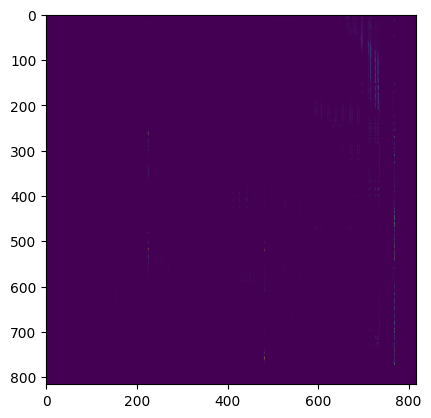

In [25]:
plt.imshow(pali_attn_patterns[12].detach().cpu().float().numpy()[0,5])

In [26]:
# plt.imshow(pali_attn_patterns[12].detach().cpu().float().numpy()[0,5], 
#            vmin=0, 
#            vmax=pali_attn_patterns[12].detach().cpu().float().quantile(0.99).item())

In [27]:
# plt.imshow(pali_attn_patterns[12].detach().cpu().float().numpy()[0,0], 
#            vmin=0, 
#            vmax=pali_attn_patterns[12].detach().cpu().float().quantile(0.99).item())

In [28]:
# layer_idx = 12
# head = 5

# attn = pali_attn_patterns[layer_idx][0, head].float()

# # log(softmax(logits)) = logits - logsumexp(logits)
# # So log(attn) recovers the logits up to a per-row constant
# # This preserves all the relative structure
# log_attn = torch.log(attn + 1e-10)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# im0 = axes[0].imshow(log_attn.numpy(), cmap='viridis',
#                        vmin=log_attn[log_attn > -20].quantile(0.05).item(),
#                        vmax=log_attn[log_attn > -20].quantile(0.95).item())
# axes[0].set_title("Log attention (≈ logits up to row constant)")
# plt.colorbar(im0, ax=axes[0])

# im1 = axes[1].imshow(attn.numpy(), cmap='viridis',
#                        vmin=0, 
#                        vmax=attn.quantile(0.99).item())
# axes[1].set_title("Attention weights (clipped at 99th percentile)")
# plt.colorbar(im1, ax=axes[1])

# for ax in axes:
#     for boundary in [256, 512, 768]:
#         ax.axhline(y=boundary, color='cyan', linewidth=0.5, alpha=0.7)
#         ax.axvline(x=boundary, color='cyan', linewidth=0.5, alpha=0.7)

# plt.tight_layout()
# plt.show()

## 7. Flow Matching Denoising Loop

10 Euler steps from t=1 (noise) to t=0 (actions).
Each step embeds the suffix (state + noisy actions + timestep), runs the action expert
with the cached prefix KV, and takes an Euler step.

In [29]:
num_steps = 10
dt = -1.0 / num_steps

# Start from fixed noise
noise_pt = torch.from_numpy(fixed_noise).to(device)[None, ...]  # [1, 50, 32]
x_t = noise_pt.clone()

# Collect trajectory for visualization
trajectory = [x_t[0].cpu().numpy().copy()]
velocities = []
t = 1.0

with torch.no_grad():
    for step in range(num_steps):
        timestep = torch.tensor([t], dtype=torch.float32, device=device)

        # === Embed suffix: state token + action/time tokens ===
        suffix_embs, suffix_pad_masks, suffix_att_masks, adarms_cond = pt_model.embed_suffix(
            state, x_t, timestep
        )
        if step == 0:
            print(f"suffix_embs: {suffix_embs.shape}")       # [1, 51, 1024] = 1 state + 50 action
            print(f"suffix_pad_masks: {suffix_pad_masks.shape}")
            print(f"suffix_att_masks: {suffix_att_masks.shape}")
            print(f"adarms_cond: {adarms_cond}")              # None for pi0

        # === Build attention mask ===
        # suffix queries attend to [prefix KV cache | suffix tokens]
        suffix_len = suffix_pad_masks.shape[1]
        batch_size = prefix_pad_masks.shape[0]
        prefix_len = prefix_pad_masks.shape[1]

        prefix_cross_mask = prefix_pad_masks[:, None, :].expand(batch_size, suffix_len, prefix_len)
        suffix_att_2d = make_att_2d_masks(suffix_pad_masks, suffix_att_masks)
        full_att_2d = torch.cat([prefix_cross_mask, suffix_att_2d], dim=2)

        if step == 0:
            print(f"full_att_2d: {full_att_2d.shape}")  # [1, 51, 816+51]

        # Suffix positions continue from where prefix left off
        prefix_offsets = torch.sum(prefix_pad_masks, dim=-1)[:, None]
        suffix_positions = prefix_offsets + torch.cumsum(suffix_pad_masks, dim=1) - 1

        # Convert to 4D mask
        full_att_4d = pt_model._prepare_attention_masks_4d(full_att_2d)

        # Set eager attention for action expert too
        pt_model.paligemma_with_expert.gemma_expert.model.config._attn_implementation = "eager"

        # === Forward pass: [None, suffix_embs] — action expert runs, PaliGemma skipped ===
        (prefix_out, suffix_out), _ = pt_model.paligemma_with_expert.forward(
            attention_mask=full_att_4d,
            position_ids=suffix_positions,
            past_key_values=kv_cache,
            inputs_embeds=[None, suffix_embs],
            use_cache=False,
            adarms_cond=[None, adarms_cond],
        )
        assert prefix_out is None

        # Extract velocity from last 50 tokens (action tokens, excluding state token)
        action_out = suffix_out[:, -pt_model.config.action_horizon:]
        v_t = pt_model.action_out_proj(action_out.to(torch.float32))

        if step == 0:
            print(f"\nv_t (velocity): {v_t.shape}")  # [1, 50, 32]

        # Euler step
        x_t = x_t + dt * v_t
        t = t + dt

        trajectory.append(x_t[0].cpu().numpy().copy())
        velocities.append(v_t[0].cpu().numpy().copy())
        print(f"  step {step}: t={t-dt:.1f}->{t:.1f}, |v_t|={v_t.norm():.2f}, |x_t|={x_t.norm():.2f}")

suffix_embs: torch.Size([1, 51, 1024])
suffix_pad_masks: torch.Size([1, 51])
suffix_att_masks: torch.Size([1, 51])
adarms_cond: None
full_att_2d: torch.Size([1, 51, 867])

v_t (velocity): torch.Size([1, 50, 32])
  step 0: t=1.0->0.9, |v_t|=41.55, |x_t|=35.79
  step 1: t=0.9->0.8, |v_t|=41.40, |x_t|=31.88
  step 2: t=0.8->0.7, |v_t|=41.42, |x_t|=28.03
  step 3: t=0.7->0.6, |v_t|=41.40, |x_t|=24.29
  step 4: t=0.6->0.5, |v_t|=41.37, |x_t|=20.69
  step 5: t=0.5->0.4, |v_t|=41.40, |x_t|=17.33
  step 6: t=0.4->0.3, |v_t|=41.35, |x_t|=14.39
  step 7: t=0.3->0.2, |v_t|=41.32, |x_t|=12.16
  step 8: t=0.2->0.1, |v_t|=41.22, |x_t|=11.09
  step 9: t=0.1->0.0, |v_t|=41.24, |x_t|=11.50


- How exaclty are models used together?
- What do attention patterns look like?


```
        (prefix_out, suffix_out), _ = pt_model.paligemma_with_expert.forward(
            attention_mask=full_att_4d,
            position_ids=suffix_positions,
            past_key_values=kv_cache,
            inputs_embeds=[None, suffix_embs],
            use_cache=False,
            adarms_cond=[None, adarms_cond],
        )
```

Hmm I think I might need to sketch this out, and then Chat with Claude some more.

## 8. Compare Against Reference

In [30]:
# Apply the same output transforms to our manually denoised actions
outputs_manual = {
    "state": np.asarray(inputs_pt["state"][0].cpu()),
    "actions": x_t[0].cpu().numpy(),
}
outputs_manual = policy._output_transform(outputs_manual)

max_diff = np.max(np.abs(result_ref["actions"] - outputs_manual["actions"]))
print(f"Max diff vs reference: {max_diff:.2e}")
print(f"All close (atol=1e-4): {np.allclose(result_ref['actions'], outputs_manual['actions'], atol=1e-4)}")
print(f"All close (atol=1e-3): {np.allclose(result_ref['actions'], outputs_manual['actions'], atol=1e-3)}")

Max diff vs reference: 8.72e-04
All close (atol=1e-4): False
All close (atol=1e-3): True


## 9. Compare: Using denoise_step (cleaner API)

The PyTorch model has a nice self-contained `denoise_step` method.
Let's verify it matches our manual loop, then use it going forward.

In [31]:
# Re-run using the model's denoise_step method
x_t_v2 = noise_pt.clone()
t_v2 = 1.0

with torch.no_grad():
    for step in range(num_steps):
        timestep = torch.tensor(t_v2, dtype=torch.float32, device=device).expand(1)
        v_t = pt_model.denoise_step(
            state, prefix_pad_masks, kv_cache, x_t_v2, timestep
        )
        x_t_v2 = x_t_v2 + dt * v_t
        t_v2 += dt

diff_v2 = (x_t_v2 - x_t).abs().max().item()
print(f"Max diff (manual loop vs denoise_step): {diff_v2:.2e}")

Max diff (manual loop vs denoise_step): 0.00e+00


## 10. Plot Predicted vs Ground Truth Actions

In [32]:
predicted_actions = outputs_manual["actions"]

In [33]:
# Gather ground truth actions for the next action_horizon frames
action_horizon = predicted_actions.shape[0]
n_gt = min(action_horizon, len(episode) - FRAME_IDX)

gt_actions = np.array([episode[FRAME_IDX + t]["action"] for t in range(n_gt)])
print(f"Ground truth actions: {gt_actions.shape}")
print(f"Predicted actions: {predicted_actions.shape}")

Ground truth actions: (50, 14)
Predicted actions: (50, 14)


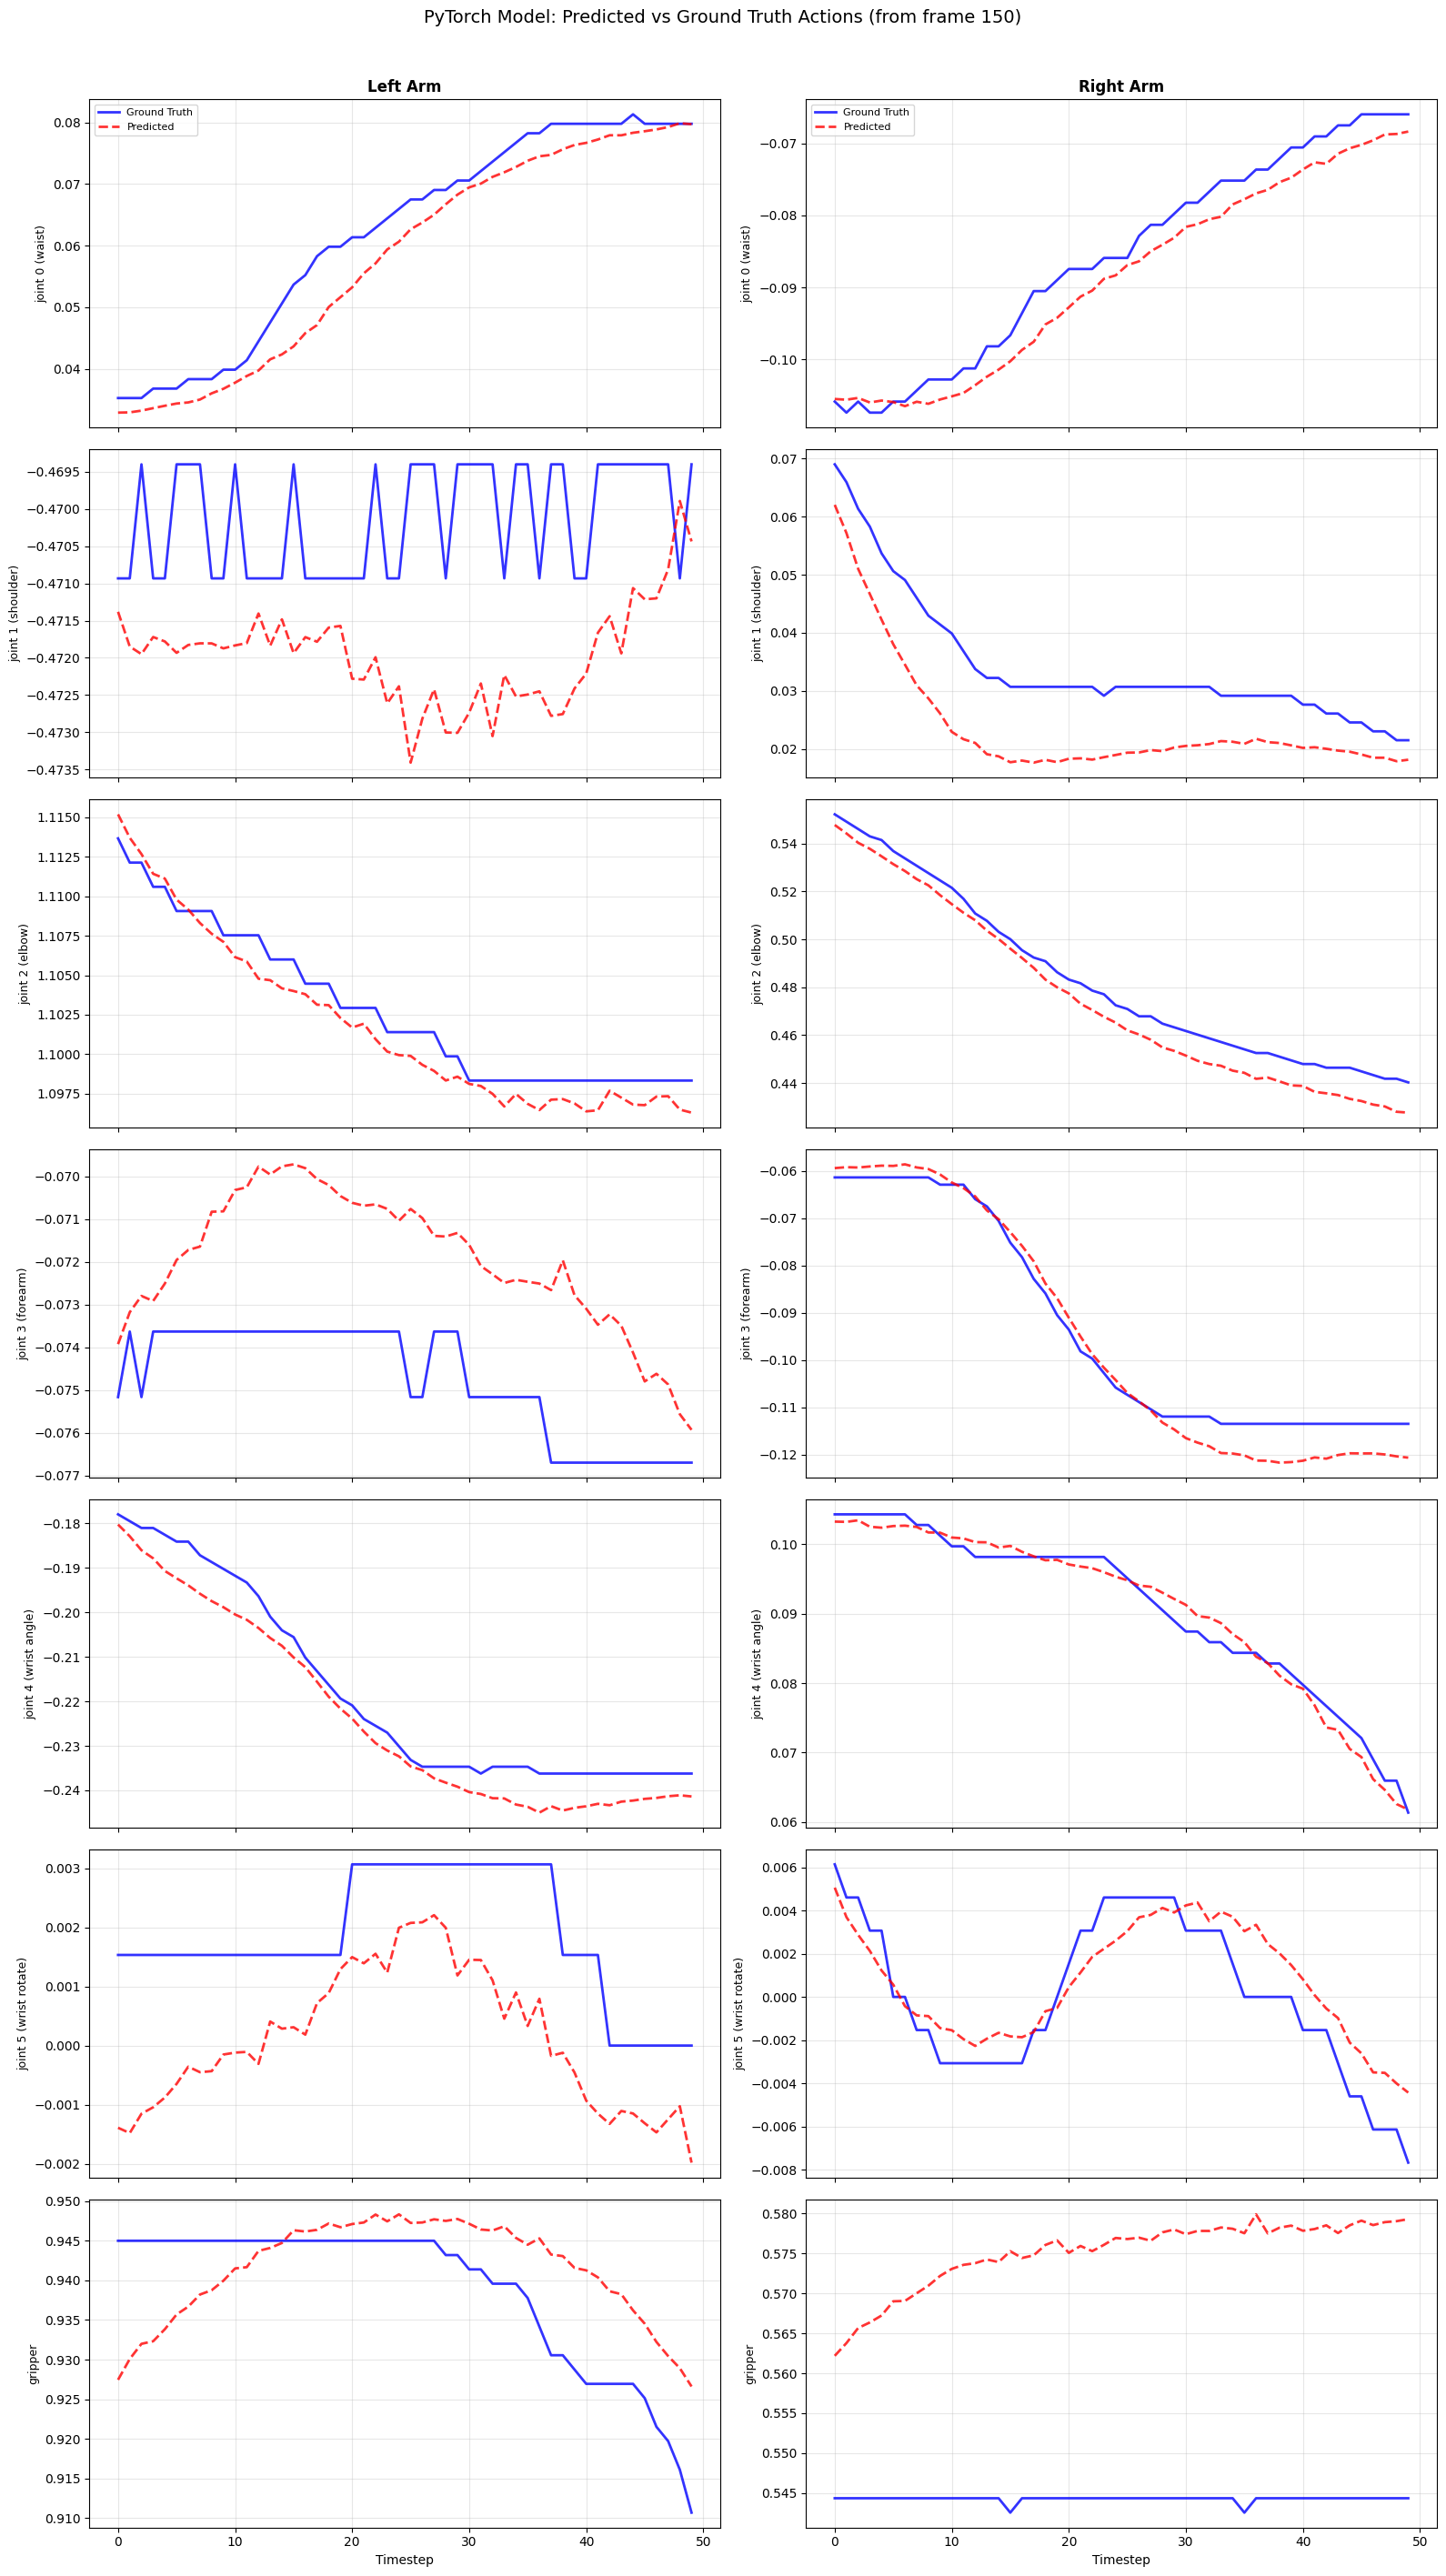

In [34]:
# Plot predicted vs ground truth for each joint
fig, axes = plt.subplots(7, 2, figsize=(16, 28), sharex=True)
time_steps = np.arange(n_gt)

for arm_idx, arm_name in enumerate(["Left", "Right"]):
    offset = arm_idx * 7
    for joint_idx in range(7):
        ax = axes[joint_idx, arm_idx]
        dim = offset + joint_idx
        
        ax.plot(time_steps, gt_actions[:n_gt, dim], 'b-', linewidth=2, label='Ground Truth', alpha=0.8)
        ax.plot(time_steps, predicted_actions[:n_gt, dim], 'r--', linewidth=2, label='Predicted', alpha=0.8)
        
        ax.set_ylabel(joint_labels[dim].replace(f"{arm_name[0]} ", ""), fontsize=9)
        ax.grid(True, alpha=0.3)
        if joint_idx == 0:
            ax.set_title(f"{arm_name} Arm", fontsize=12, fontweight='bold')
            ax.legend(fontsize=8)
        if joint_idx == 6:
            ax.set_xlabel("Timestep")

plt.suptitle(f"PyTorch Model: Predicted vs Ground Truth Actions (from frame {FRAME_IDX})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()